# Перенос художественного стиля

In [1]:
import sys
print('Python kernel:', sys.executable)
print('Python version:', sys.version)


Python kernel: c:\Users\aleks\AppData\Local\Programs\Python\Python311\python.exe
Python version: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


## Настройка путей


In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"

WIKIART_DIR = Path(
    r"C:\Users\aleks\Downloads\wikiart"
)

CONTENT_DIR = DATA_DIR / "content_images"
STYLE_DIR = DATA_DIR / "style_images"

MODELS_DIR = PROJECT_DIR / "models"
HUB_CACHE_DIR = MODELS_DIR / "tfhub_cache"
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

HUB_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR = PROJECT_DIR / "results"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in [
    DATA_DIR,
    CONTENT_DIR,
    STYLE_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Папка проекта:", PROJECT_DIR)
print("Папка WikiArt:", WIKIART_DIR)
print("WikiArt существует:", WIKIART_DIR.exists())
print("WikiArt является папкой:", WIKIART_DIR.is_dir())

if not WIKIART_DIR.is_dir():
    raise FileNotFoundError(
        f"Папка WikiArt не найдена:\n{WIKIART_DIR}"
    )

Папка проекта: c:\Users\aleks\Documents\IDE\PROJECT-4-andr
Папка WikiArt: C:\Users\aleks\Downloads\wikiart
WikiArt существует: True
WikiArt является папкой: True


## Импорты


In [3]:
import os
import sys
import shutil
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub

from PIL import Image, ImageFile
from tqdm import tqdm


ImageFile.LOAD_TRUNCATED_IMAGES = True


print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)
print("TensorFlow Hub:", hub.__version__)

c:\Users\aleks\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



Python: c:\Users\aleks\AppData\Local\Programs\Python\Python311\python.exe
TensorFlow: 2.16.1
TensorFlow Hub: 0.16.1


## Поиск и проверка изображений WikiArt


In [4]:
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

def find_image_files(directory):
    directory = Path(directory)
    return sorted([
        path for path in directory.rglob('*')
        if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS
    ])

def is_valid_image(path, min_width=128, min_height=128):
    try:
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            width, height = image.size
        return width >= min_width and height >= min_height
    except Exception:
        return False

wikiart_paths = find_image_files(WIKIART_DIR)
print(f'Найдено изображений: {len(wikiart_paths):,}')

if not wikiart_paths:
    print('В папке нет файлов изображений. Первые объекты папки:')
    for path in list(WIKIART_DIR.rglob('*'))[:30]:
        print(path)
    raise ValueError('В указанной папке WikiArt не найдено изображений.')


Найдено изображений: 71,446


In [5]:
valid_wikiart_paths = []

for path in tqdm(wikiart_paths, desc='Проверка WikiArt'):
    if is_valid_image(path):
        valid_wikiart_paths.append(path)

print(f'Валидных изображений: {len(valid_wikiart_paths):,}')

if not valid_wikiart_paths:
    raise ValueError('В папке WikiArt не найдено валидных изображений.')

index_path = REPORTS_DIR / 'wikiart_valid_images.csv'
pd.DataFrame({'path': [str(path) for path in valid_wikiart_paths]}).to_csv(index_path, index=False)
print('Список валидных изображений сохранён:', index_path)


Проверка WikiArt: 100%|██████████| 71446/71446 [01:54<00:00, 626.02it/s]


Валидных изображений: 71,446
Список валидных изображений сохранён: c:\Users\aleks\Documents\IDE\PROJECT-4-andr\reports\wikiart_valid_images.csv


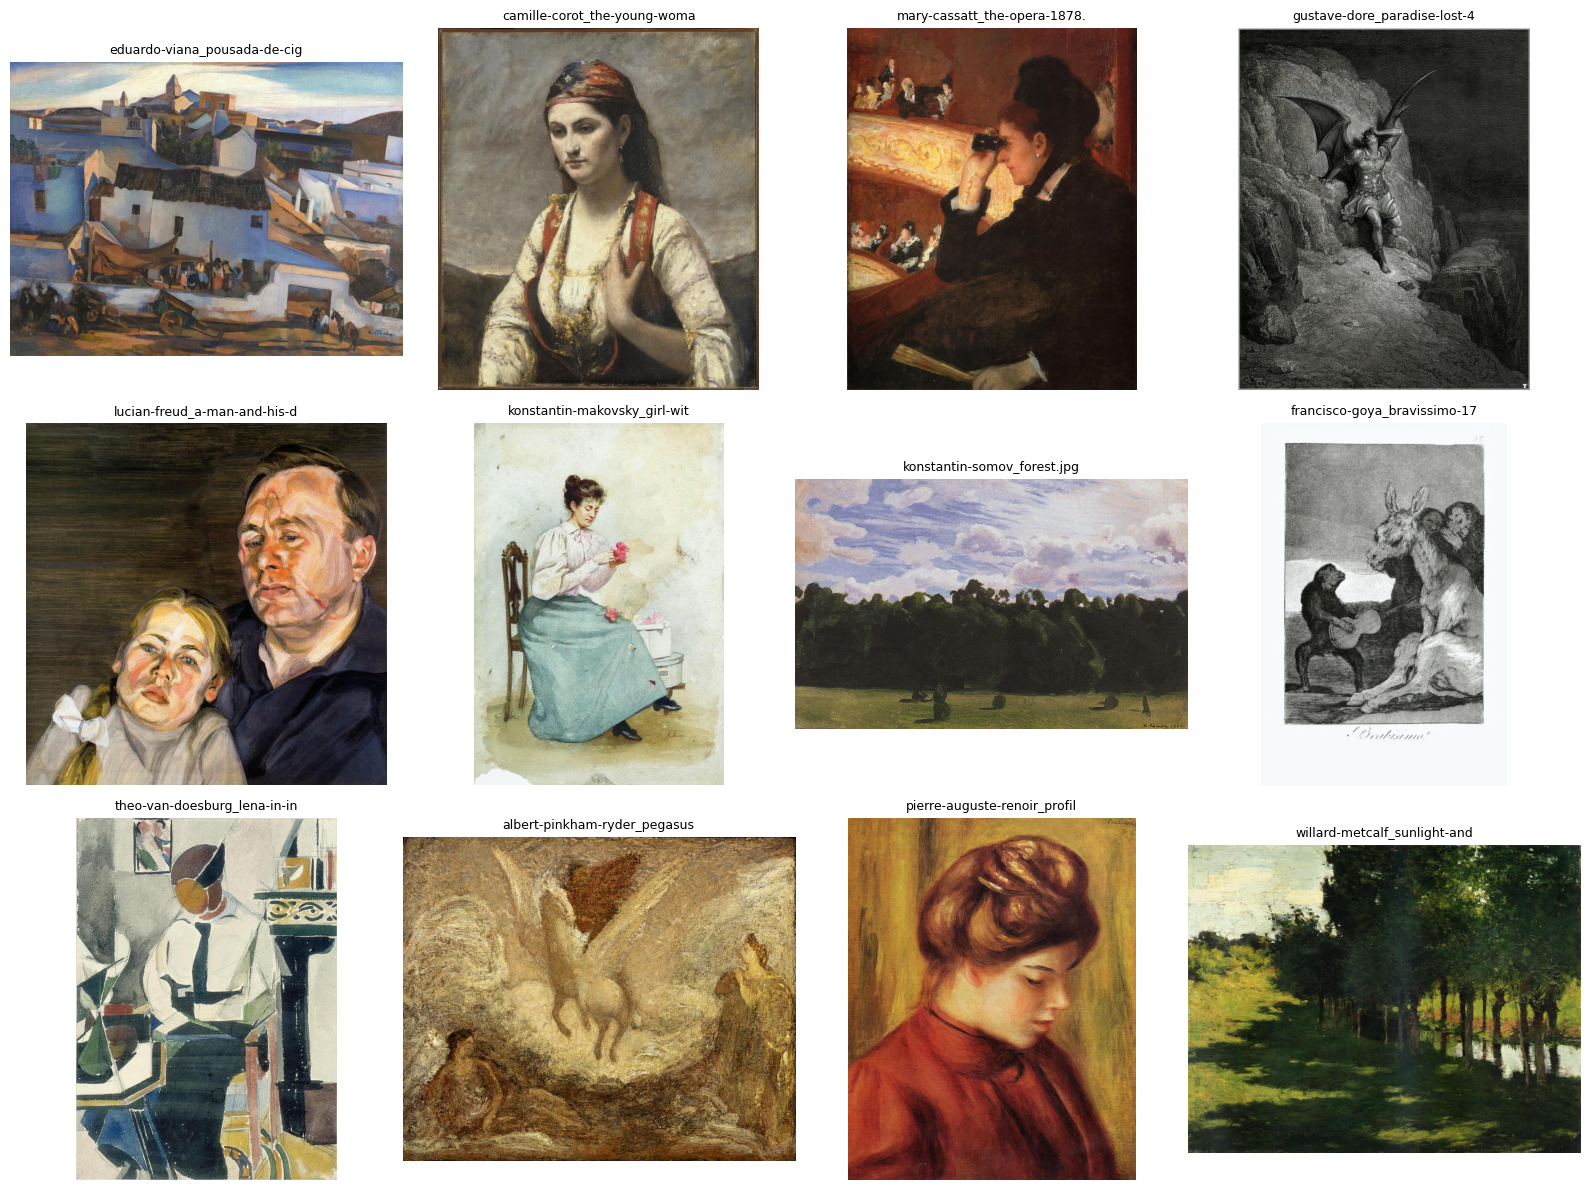

In [6]:
def show_images(paths, cols=4, figsize=(16, 12)):
    paths = list(paths)
    rows = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=figsize)
    for index, path in enumerate(paths, start=1):
        plt.subplot(rows, cols, index)
        plt.imshow(Image.open(path).convert('RGB'))
        plt.title(Path(path).name[:28], fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

sample_paths = random.sample(valid_wikiart_paths, min(12, len(valid_wikiart_paths)))
show_images(sample_paths)


## Отбор стилевых изображений

Для тестов и int8-калибровки не нужно дублировать весь WikiArt. Ноутбук копирует ограниченное число валидных картин в `data/style_images`.


Подготовлено стилевых изображений: 30


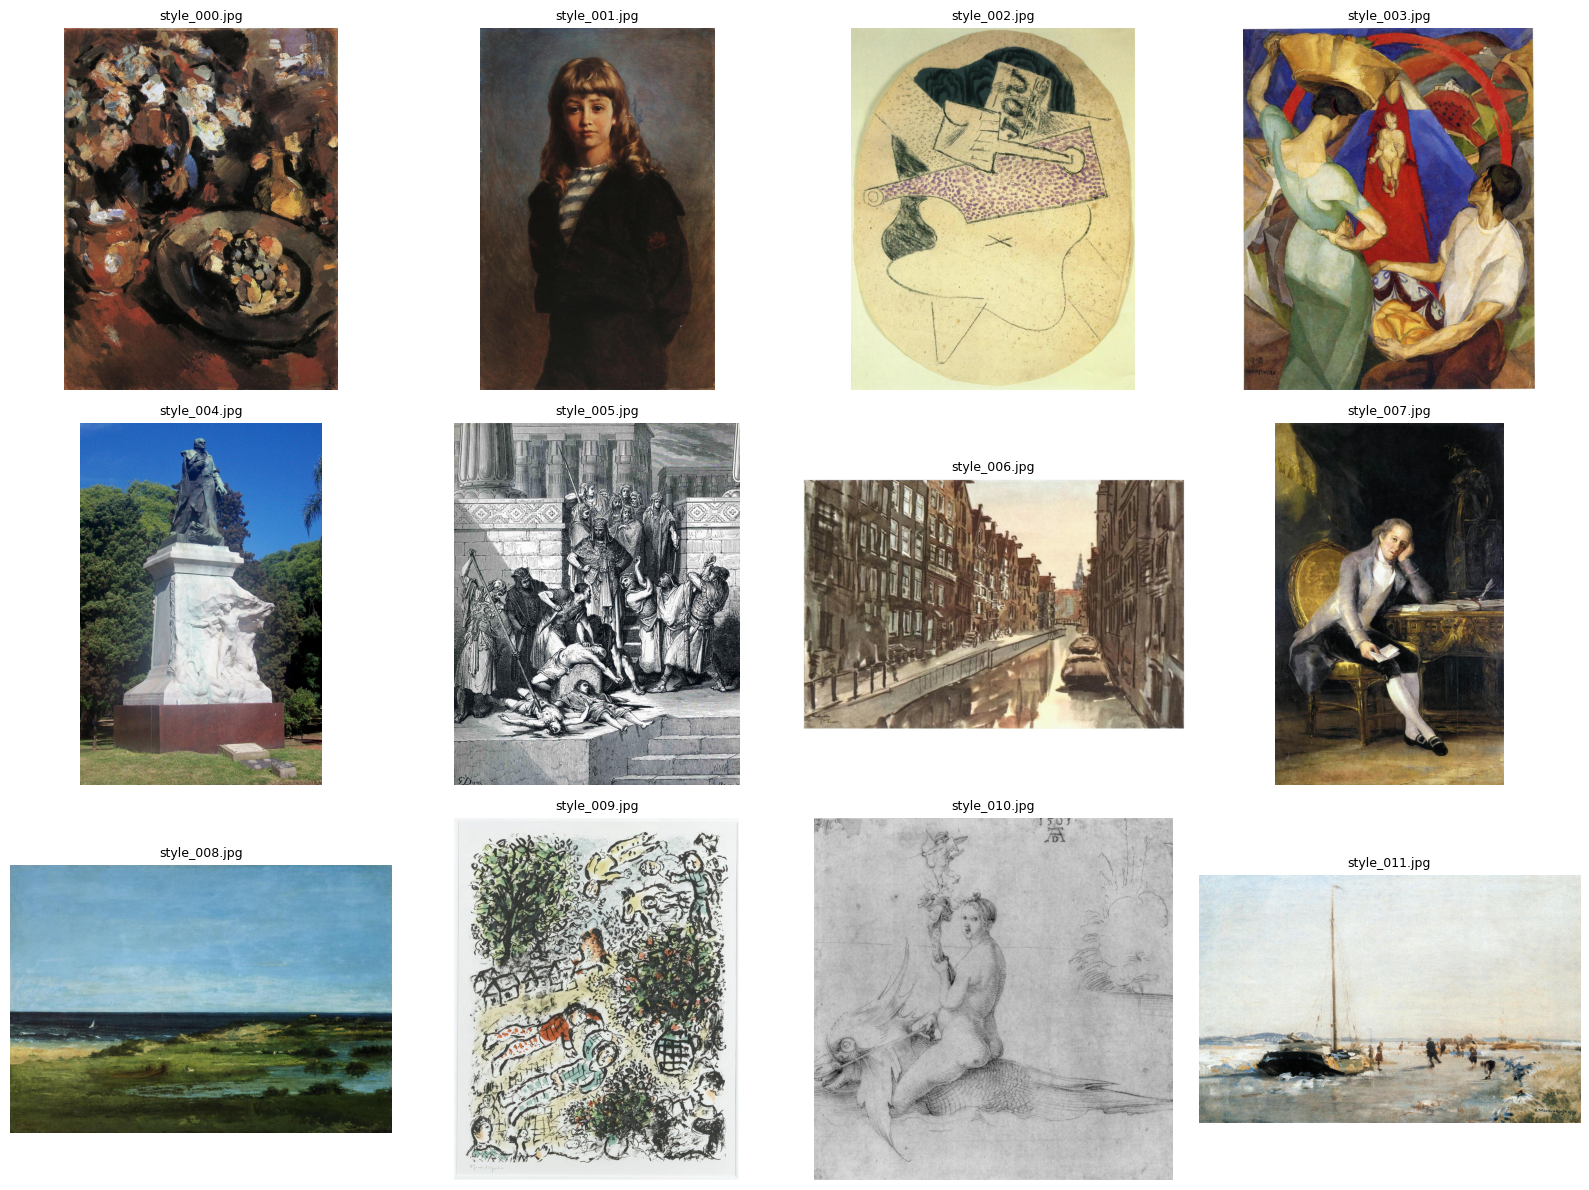

In [7]:
N_STYLE_IMAGES = 30

# Очищаем ранее отобранные стили, чтобы результат был воспроизводимым.
for path in STYLE_DIR.iterdir():
    if path.is_file():
        path.unlink()

selected_style_paths = random.sample(
    valid_wikiart_paths,
    min(N_STYLE_IMAGES, len(valid_wikiart_paths))
)

style_paths = []
for index, source_path in enumerate(selected_style_paths):
    target_path = STYLE_DIR / f'style_{index:03d}{source_path.suffix.lower()}'
    shutil.copy2(source_path, target_path)
    style_paths.append(target_path)

print('Подготовлено стилевых изображений:', len(style_paths))
show_images(style_paths[:min(12, len(style_paths))])


## Контентные изображения

 фотографий в `data/content_images`


Контентных изображений найдено: 1


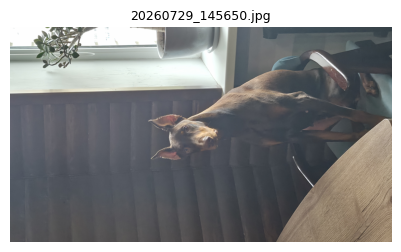

In [8]:
content_paths = find_image_files(CONTENT_DIR)
print('Контентных изображений найдено:', len(content_paths))

if not content_paths:
    raise ValueError(
        'Добавьте фотографии в data/content_images и повторите эту ячейку.'
    )

show_images(content_paths[:min(12, len(content_paths))])


## Вспомогательные функции обработки изображений


In [9]:
def load_image_tensor(path, image_size):
    image = tf.io.read_file(str(path))
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, image_size)
    return tf.expand_dims(image, axis=0)

def show_tensor_image(image, title=None):
    image = image.numpy() if isinstance(image, tf.Tensor) else image
    if image.ndim == 4:
        image = image[0]
    plt.figure(figsize=(6, 6))
    plt.imshow(np.clip(image, 0, 1))
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

def save_tensor_image(image, path):
    image = image.numpy() if isinstance(image, tf.Tensor) else image
    if image.ndim == 4:
        image = image[0]
    image = (np.clip(image, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(image).save(path)
    print('Сохранено:', path)


## Скачивание предобученных моделей Magenta


In [10]:
import os
from pathlib import Path
import tensorflow_hub as hub

HUB_CACHE_DIR = Path(r"C:\tfhub_cache")

HUB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if not HUB_CACHE_DIR.is_dir():
    raise RuntimeError(
        f"Не удалось создать папку кэша: {HUB_CACHE_DIR}"
    )

os.environ["TFHUB_CACHE_DIR"] = str(HUB_CACHE_DIR)

HUB_MODEL_URL = (
    "https://tfhub.dev/google/magenta/"
    "arbitrary-image-stylization-v1-256/2"
)

print("Папка кэша TensorFlow Hub:")
print(HUB_CACHE_DIR)

print("\nЗагрузка Magenta-модели...")

hub_model = hub.load(HUB_MODEL_URL)

print("\nМодель загружена.")
print("Модель сохранена в кэше:")
print(HUB_CACHE_DIR)

Папка кэша TensorFlow Hub:
C:\tfhub_cache

Загрузка Magenta-модели...




Модель загружена.
Модель сохранена в кэше:
C:\tfhub_cache


## Проверка переноса художественного стиля

В качестве контентного изображения используется обычная фотография из
папки `data/content_images`.

В качестве стилевого изображения используется картина из датасета WikiArt.

Предобученная модель Magenta получает оба изображения и формирует
стилизованный результат.

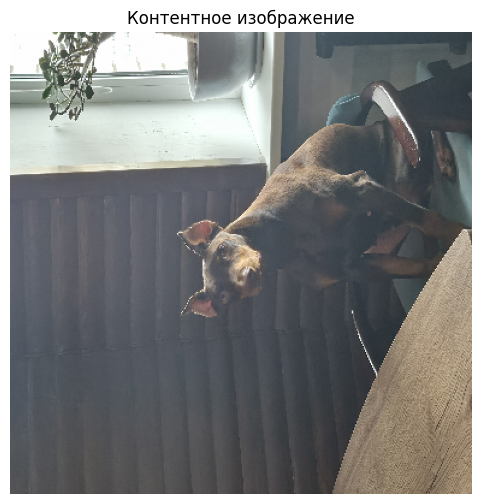

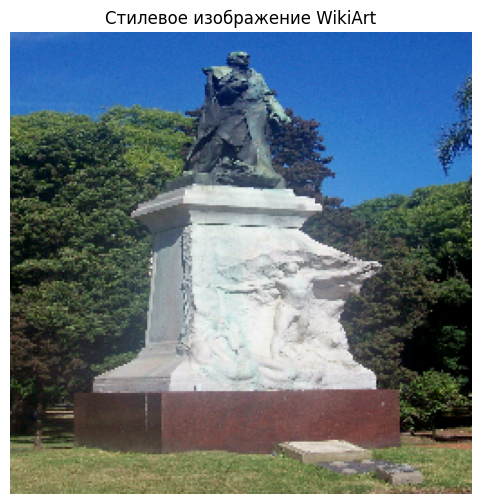

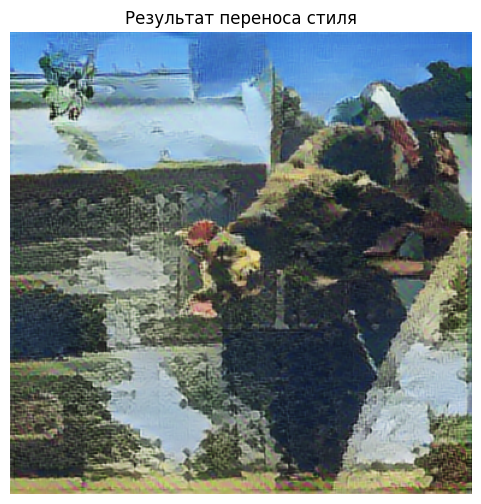

In [11]:
import random

# Выбираем случайные контент и стиль
content_idx = random.randint(0, len(content_paths) - 1)
style_idx = random.randint(0, len(style_paths) - 1)

content_path = content_paths[content_idx]
style_path = style_paths[style_idx]


content_image = load_image_tensor(
    content_path,
    image_size=(384, 384),
)


style_image = load_image_tensor(
    style_path,
    image_size=(256, 256),
)


show_tensor_image(
    content_image,
    "Контентное изображение",
)


show_tensor_image(
    style_image,
    "Стилевое изображение WikiArt",
)


stylized_image = hub_model(
    tf.constant(content_image),
    tf.constant(style_image),
)[0]


show_tensor_image(
    stylized_image,
    "Результат переноса стиля",
)

In [12]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

output_path = RESULTS_DIR / (
    f"magenta_style_transfer_{timestamp}.jpg"
)

save_tensor_image(
    stylized_image,
    output_path,
)

Сохранено: c:\Users\aleks\Documents\IDE\PROJECT-4-andr\results\magenta_style_transfer_20261007_195345.jpg
